# Alejandro Reynoso — GitHub to Obsidian Vault Builder

##Reference

https://chatgpt.com/share/6a5787b0-4438-83e8-8e0d-f8f03702939d

##Overview

This notebook creates an Obsidian vault from the public repositories in the GitHub account `alexdibol`.

It creates:
- A home dashboard
- One note per repository
- Individual notes extracted from numbered entries in the `papers` README
- Topic notes and backlinks
- An Obsidian Canvas research map
- A ZIP file ready to download and open as an Obsidian vault


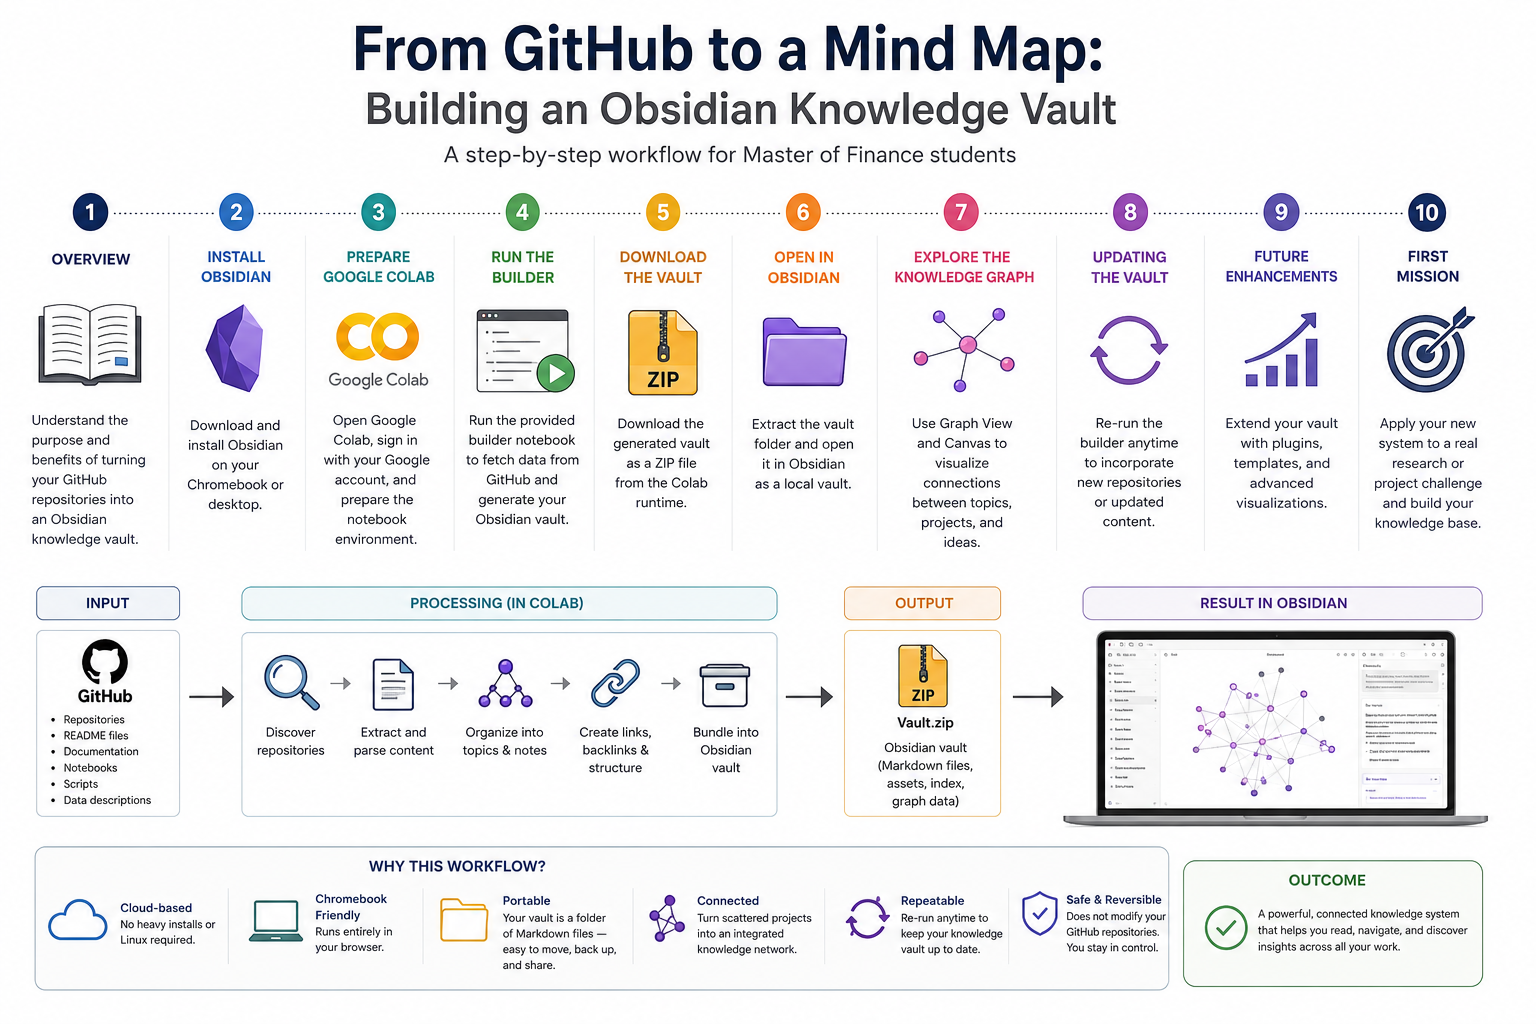

##Code and Implementation

This initial code cell serves as the configuration hub for the entire notebook. It defines essential parameters that govern how the GitHub repository data will be processed and how the Obsidian vault will be structured. Key variables include `GITHUB_OWNER`, specifying the GitHub username whose repositories are to be fetched, and `VAULT_NAME`, which sets the name for the output Obsidian vault. An optional `GITHUB_TOKEN` is included, highly recommended for increased API limits and potential access to private repositories, although it's currently left blank for public repo access. Safety limits like `MAX_REPOSITORIES` (set to 200) prevent excessive API calls, while boolean flags like `PROCESS_PAPERS_README` and `CREATE_CANVAS` enable or disable specific features, such as extracting papers from a dedicated README or generating an Obsidian Canvas map. The cell concludes by printing a confirmation message, 'Configuration loaded.', indicating that these foundational settings have been established, preparing the environment for subsequent operations.

In [1]:
# 1. CONFIGURATION
GITHUB_OWNER = "alexdibol"
VAULT_NAME = "Alejandro-Reynoso-Knowledge-Vault"

# Optional but recommended. Leave blank for public repositories.
# A token raises GitHub API limits and may allow access to private repositories
# if the token has the appropriate read permissions.
GITHUB_TOKEN = ""

# Safety limits for the first version
MAX_REPOSITORIES = 200
PROCESS_PAPERS_README = True
CREATE_CANVAS = True

print("Configuration loaded.")

Configuration loaded.


This cell is crucial for setting up the necessary tools and directory structure for the Obsidian vault creation process. It begins by importing several standard Python libraries: `os`, `re` (for regular expressions), `json`, `shutil` (for high-level file operations), `textwrap`, `time`, and `requests` (for making HTTP requests to the GitHub API). The `Path` object from `pathlib` is used to define a structured directory layout for the new Obsidian vault, creating `ROOT`, `REPOS_DIR`, `PAPERS_DIR`, `TOPICS_DIR`, and `MAPS_DIR`. These directories are then created on the file system using `mkdir(parents=True, exist_ok=True)`, ensuring the vault's foundational folder structure is in place. It also initializes a `headers` dictionary for GitHub API requests, optionally including an `Authorization` token if `GITHUB_TOKEN` was provided in the configuration. Several helper functions are defined: `safe_name` sanitizes text for use as file names, `yaml_quote` formats strings for YAML frontmatter, and `write_text` writes content to specified file paths, creating parent directories as needed. Most importantly, `TOPIC_RULES` is a dictionary mapping broad research themes to keywords, and the `infer_topics` function uses these rules to automatically tag content based on keywords found in text. Finally, it confirms the creation of the vault's root folder.

In [ ]:
# 2. IMPORTS AND HELPERS
import os, re, json, shutil, textwrap, time
from pathlib import Path
from urllib.parse import quote
import requests

ROOT = Path('/content') / VAULT_NAME
REPOS_DIR = ROOT / 'Repositories'
PAPERS_DIR = ROOT / 'Working Papers'
TOPICS_DIR = ROOT / 'Topics'
MAPS_DIR = ROOT / 'Maps'

for folder in [ROOT, REPOS_DIR, PAPERS_DIR, TOPICS_DIR, MAPS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

headers = {'Accept': 'application/vnd.github+json'}
if GITHUB_TOKEN.strip():
    headers['Authorization'] = f'Bearer {GITHUB_TOKEN.strip()}'

def safe_name(text, max_len=140):
    text = re.sub(r'[\\/:*?"<>|#^\[\]]+', '-', str(text))
    text = re.sub(r'\s+', ' ', text).strip(' .-')
    return (text[:max_len].rstrip() or 'Untitled')

def yaml_quote(value):
    return json.dumps(str(value), ensure_ascii=False)

def write_text(path, text):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8')

TOPIC_RULES = {
    'Artificial Intelligence': ['artificial intelligence', ' ai ', 'machine learning', 'deep learning', 'generative'],
    'Agentic AI': ['agentic', 'multi-agent', 'autonomous agent', 'agents'],
    'Algorithmic Trading': ['algorithmic trading', 'trading system', 'market microstructure', 'order book', 'strategy'],
    'AI Governance': ['governance', 'audit', 'risk boundary', 'responsible ai', 'model risk'],
    'Quantum Finance': ['quantum', 'qaoa', 'qubit', 'shor', 'grover'],
    'Financial Innovation': ['financial innovation', 'fintech', 'payments', 'tokenization'],
    'Portfolio Management': ['portfolio', 'asset allocation', 'wealth management', 'investment advisor'],
    'Systemic Risk': ['systemic risk', 'financial stability', 'contagion'],
    'Bayesian Methods': ['bayesian', 'posterior', 'prior distribution'],
    'Legal AI': ['legal', 'litigation', 'law'],
    'Accounting AI': ['accounting', 'audit evidence'],
    'Education': ['course', 'teaching', 'education', 'curriculum'],
}

def infer_topics(text):
    low = f' {text.lower()} '
    topics = []
    for topic, words in TOPIC_RULES.items():
        if any(word in low for word in words):
            topics.append(topic)
    return topics or ['Research']

print(f'Vault folders created at {ROOT}')

Vault folders created at /content/Alejandro-Reynoso-Knowledge-Vault


This cell is responsible for querying the GitHub API to retrieve a list of all public repositories belonging to the specified `GITHUB_OWNER`. It initializes an empty list `repos` to store the fetched repository data and sets a `page` counter to 1 for paginated API requests. The `while` loop continues to fetch repositories as long as the total number of `repos` collected is less than `MAX_REPOSITORIES` (defined in the configuration). Inside the loop, it constructs the GitHub API URL for fetching user repositories and makes a `GET` request using the `requests` library. The `headers` dictionary, which may include an authorization token, is passed to authenticate the request and `params` are set to fetch 100 repositories per page and sort them by update time. The `response.raise_for_status()` call ensures that any HTTP errors are immediately flagged. If the request is successful, the JSON response containing a batch of repositories is appended to the `repos` list. The loop breaks if an empty batch is received, indicating no more repositories, or if the `MAX_REPOSITORIES` limit is reached. Finally, the list of `repos` is truncated to ensure it doesn't exceed `MAX_REPOSITORIES`, and the cell prints the total number of repositories found for the GitHub owner, confirming the successful inventory download.

In [ ]:
# 3. DOWNLOAD THE REPOSITORY INVENTORY
repos = []
page = 1
while len(repos) < MAX_REPOSITORIES:
    url = f'https://api.github.com/users/{GITHUB_OWNER}/repos'
    response = requests.get(url, headers=headers, params={'per_page': 100, 'page': page, 'sort': 'updated'}, timeout=30)
    response.raise_for_status()
    batch = response.json()
    if not batch:
        break
    repos.extend(batch)
    page += 1

repos = repos[:MAX_REPOSITORIES]
print(f'Found {len(repos)} public repositories for {GITHUB_OWNER}.')

Found 44 public repositories for alexdibol.


This cell iterates through each fetched GitHub repository, retrieves its README content, and generates a corresponding Markdown note for the Obsidian vault. It starts by defining a helper function, `fetch_readme`, which makes an authenticated API call to get the raw README content for a given repository, handling cases where a README might not exist (returning an empty string) or encountering other HTTP errors. The main logic then initializes `repo_records` (to store metadata about each generated note) and `topic_to_notes` (to map topics to notes for later index creation). For each repository in the `repos` list, it attempts to fetch the README. It then extracts the repository's name and description. The `combined` string is created by concatenating the name, description, and an excerpt of the README; this is used by the `infer_topics` function (defined in cell 2) to automatically assign relevant topics to the repository. A `note_name` is generated using `safe_name` to ensure it's a valid file name. The cell then constructs the full Markdown content for the Obsidian note. This includes YAML frontmatter with metadata like `type`, `github_owner`, `repository` URL, update time, and the inferred `topics`. The note's body contains a title, description, a list of topic links (using Obsidian's internal link format `[[Topic]]`), a link to the GitHub repository, and an excerpt of the README. This structured note is then written to a `.md` file within the `Repositories` directory of the vault. The `repo_records` and `topic_to_notes` lists are updated, and a small `time.sleep` is included to avoid hitting API rate limits. Finally, it prints the total number of repository notes created.

In [ ]:
# 4. FETCH EACH README AND CREATE ONE OBSIDIAN NOTE PER REPOSITORY
def fetch_readme(repo_name, default_branch='main'):
    api = f'https://api.github.com/repos/{GITHUB_OWNER}/{repo_name}/readme'
    r = requests.get(api, headers={**headers, 'Accept': 'application/vnd.github.raw+json'}, timeout=30)
    if r.status_code == 404:
        return ''
    r.raise_for_status()
    return r.text

repo_records = []
topic_to_notes = {}

for i, repo in enumerate(repos, 1):
    name = repo['name']
    print(f'[{i}/{len(repos)}] {name}')
    try:
        readme = fetch_readme(name, repo.get('default_branch', 'main'))
    except Exception as exc:
        print('  README warning:', exc)
        readme = ''

    description = repo.get('description') or ''
    combined = f'{name} {description} {readme[:12000]}'
    topics = infer_topics(combined)
    note_name = safe_name(name.replace('_', ' ').replace('-', ' ').title())

    frontmatter_topics = '\n'.join(f'  - {yaml_quote(t)}' for t in topics)
    topic_links = '\n'.join(f'- [[{t}]]' for t in topics)
    readme_excerpt = readme[:10000].strip() if readme else '_No README was found._'

    body = f'''---
type: repository
github_owner: {yaml_quote(GITHUB_OWNER)}
repository: {yaml_quote(name)}
url: {yaml_quote(repo['html_url'])}
default_branch: {yaml_quote(repo.get('default_branch', 'main'))}
updated_at: {yaml_quote(repo.get('updated_at', ''))}
topics:
{frontmatter_topics}
---

# {note_name}

## Description

{description or 'No GitHub description is currently available.'}

## Research themes

{topic_links}

## GitHub

[Open repository]({repo['html_url']})

## README extract

{readme_excerpt}
'''
    write_text(REPOS_DIR / f'{note_name}.md', body)
    repo_records.append({'name': name, 'note': note_name, 'url': repo['html_url'], 'topics': topics, 'readme': readme})
    for topic in topics:
        topic_to_notes.setdefault(topic, []).append(note_name)
    time.sleep(0.05)

print(f'Created {len(repo_records)} repository notes.')

[1/44] ai-prompting
[2/44] ai_summer_2026
[3/44] ai-governance_2026
[4/44] papers
[5/44] innovation_summer_2026
[6/44] quantum_essential
[7/44] alexdibol.github.io
[8/44] ai4s_financial_domain
[9/44] ai_ai4s
[10/44] ai_fifa_2026
[11/44] ai_essentials
[12/44] algo_easter_2026
[13/44] ai_easter_2026
[14/44] agents-handbook
[15/44] algo_capstone_2026
[16/44] ai-101
[17/44] algo_strategies
[18/44] algo_systems_handbook
[19/44] modern_finance
[20/44] financial_innovation
[21/44] books
[22/44] ai-self_teaching
[23/44] ai-law
[24/44] course_jbs_2026
[25/44] algo_self_teaching
[26/44] algo_course_jbs_2026
[27/44] ai-diffusion
[28/44] ai-bayesian
[29/44] ai-governance_first
[30/44] ai-reasoning
[31/44] ai-memory
[32/44] ai-surrogates
[33/44] ai-multimodal
[34/44] ai-algo-trading-notebooks
[35/44] algo_systems
[36/44] markets_for_traders
[37/44] ai-governed_generative_applications
[38/44] ml-governance_first
[39/44] ai-fine_tuning
[40/44] ai-financial_advisors
[41/44] ai-consulting
[42/44] ai-ac

This cell focuses on extracting structured information from a specific 'papers' repository's README, if it exists and `PROCESS_PAPERS_README` is enabled. It's designed to parse numbered entries (e.g., '## 1. Title') typically found in a curated list of working papers. First, an empty list `paper_records` is initialized to store details about each extracted paper. A `clean_markdown` helper function is defined to remove HTML tags and image markdown from text, ensuring clean abstracts and titles. The cell then searches `repo_records` for a repository named 'papers' (case-insensitive). If found and its README content is available, it proceeds with parsing. A regular expression `heading_re` is compiled to identify headings that follow specific numbering patterns. It iterates through all matches, extracting the paper number, title, and the section content between headings. It then tries to find links within the section and specifically searches for an 'abstract' section. If an abstract is not found, a summary of the section is used. The `infer_topics` function is used again to assign topics based on the paper's title and abstract. A unique `note_name` is created, and the full Markdown note is constructed with YAML frontmatter containing `type`, `paper_number`, `title`, author, repository, and inferred `topics`. The note body includes the title, abstract, topic links, and source links. Finally, this note is written to a file in the `Working Papers` directory, and `paper_records` and `topic_to_notes` are updated. If the 'papers' README cannot be found, an appropriate message is printed. This process generates individual Obsidian notes for each identified working paper, enriching the vault with detailed research content.

In [ ]:
# 5. EXTRACT NUMBERED WORKING PAPERS FROM THE PAPERS README
paper_records = []

def clean_markdown(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'!\S*\[[^]]*\]\([^)]*\)', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

if PROCESS_PAPERS_README:
    papers_repo = next((r for r in repo_records if r['name'].lower() == 'papers'), None)
    if papers_repo and papers_repo['readme']:
        readme = papers_repo['readme']
        # Headings such as ## 94. Title, #94 Title, or ### Paper 94: Title
        heading_re = re.compile(
            r'(?m)^(#{1,6})\s*(?:paper\s*)?#?\s*(\d{1,3})\s*[.\-:–—)]*\s*(.+?)\s*$'
        )
        matches = list(heading_re.finditer(readme))
        for idx, match in enumerate(matches):
            number = int(match.group(2))
            title = clean_markdown(match.group(3))
            start = match.end()
            end = matches[idx + 1].start() if idx + 1 < len(matches) else len(readme)
            section = readme[start:end].strip()
            links = re.findall(r'\[([^\]]+)\]\((https?://[^)]+)\)', section)
            abstract_match = re.search(
                r'(?is)(?:\*\*)?abstract(?:\*\*)?\s*[:\-]?\s*(.+?)(?=\n\s*(?:#{1,6}|\*\*?(?:keywords|reference|link|download)|$))',
                section
            )
            abstract = clean_markdown(abstract_match.group(1)) if abstract_match else clean_markdown(section[:1800])
            topics = infer_topics(f'{title} {abstract}')
            note_name = safe_name(f'WP-{number:03d} - {title}')
            topic_links = '\n'.join(f'- [[{t}]]' for t in topics)
            source_links = '\n'.join(f'- [{label}]({url})' for label, url in links) or '- [Open Papers repository](https://github.com/alexdibol/papers)'
            frontmatter_topics = '\n'.join(f'  - {yaml_quote(t)}' for t in topics)

            note = f'''---
type: working-paper
paper_number: {number}
title: {yaml_quote(title)}
author: "Alejandro Reynoso"
repository: "papers"
topics:
{frontmatter_topics}
---

# {title}

## Abstract or README summary

{abstract or 'Abstract not automatically identified.'}

## Research themes

{topic_links}

## Source material

{source_links}

## Parent collection

[[Papers]]
'''
            write_text(PAPERS_DIR / f'{note_name}.md', note)
            paper_records.append({'number': number, 'title': title, 'note': note_name, 'topics': topics})
            for topic in topics:
                topic_to_notes.setdefault(topic, []).append(note_name)

        print(f'Extracted {len(paper_records)} numbered paper notes.')
    else:
        print('The papers README could not be found.')

Extracted 92 numbered paper notes.


This cell orchestrates the creation of various navigational and organizational notes within the Obsidian vault, including individual topic notes, a central home dashboard, and comprehensive index pages for repositories and working papers. It iterates through the `topic_to_notes` dictionary (populated in previous steps), which maps each inferred topic to a list of associated repository and paper notes. For every unique topic, it generates a dedicated Markdown file in the `Topics` directory. Each topic note contains YAML frontmatter defining its type and name, followed by a heading for the topic and a list of links (Obsidian-style `[[Note Name]]`) to all relevant repository and working paper notes. This ensures robust backlinking and easy navigation within the vault. Following the creation of topic notes, the cell compiles lists of all repository and paper notes, sorted alphabetically or numerically, to create index pages. `repo_links` and `paper_links` are formatted as bulleted lists of internal Obsidian links. `topic_links` is also generated similarly. Finally, it constructs the content for the `00 - Home.md` dashboard, which acts as the vault's entry point. This dashboard includes a welcoming message, links to the main index pages (`Repository Index`, `Working Papers Index`, `Research Topics`), and a prompt to open the visual canvas. It also provides a summary of the vault's current inventory (number of repositories, extracted papers, and topics). All these dynamically generated notes (`00 - Home.md`, `Repository Index.md`, `Working Papers Index.md`, and `Research Topics.md`) are then written to the `ROOT` directory of the vault, establishing the core navigation structure. The cell concludes by confirming the creation of these indexes and topic notes, indicating a complete and interconnected vault structure.

In [ ]:
# 6. CREATE TOPIC NOTES, HOME DASHBOARD, AND INDEXES
for topic, notes in sorted(topic_to_notes.items()):
    unique_notes = sorted(set(notes))
    links = '\n'.join(f'- [[{n}]]' for n in unique_notes)
    write_text(TOPICS_DIR / f'{safe_name(topic)}.md', f'''---
type: topic
topic: {yaml_quote(topic)}
---

# {topic}

## Connected research

{links}
''')

repo_links = '\n'.join(f'- [[{r["note"]}]]' for r in sorted(repo_records, key=lambda x: x['note']))
paper_links = '\n'.join(f'- [[{p["note"]}]]' for p in sorted(paper_records, key=lambda x: x['number'], reverse=True))
topic_links = '\n'.join(f'- [[{t}]]' for t in sorted(topic_to_notes))

home = f'''---
type: dashboard
---

# Alejandro Reynoso — Knowledge Vault

> A connected map of repositories, books, courses, notebooks, and working papers.

## Start here

- [[Repository Index]]
- [[Working Papers Index]]
- [[Research Topics]]
- Open `Maps/Research Map.canvas` for the visual map.

## Current inventory

- Repositories: **{len(repo_records)}**
- Extracted working papers: **{len(paper_records)}**
- Research topics: **{len(topic_to_notes)}**
'''
write_text(ROOT / '00 - Home.md', home)
write_text(ROOT / 'Repository Index.md', '# Repository Index\n\n' + repo_links + '\n')
write_text(ROOT / 'Working Papers Index.md', '# Working Papers Index\n\n' + (paper_links or '_No papers were extracted._') + '\n')
write_text(ROOT / 'Research Topics.md', '# Research Topics\n\n' + topic_links + '\n')

print('Indexes and topic notes created.')

Indexes and topic notes created.


This cell is responsible for generating an Obsidian Canvas file, a visual mapping tool within Obsidian, if the `CREATE_CANVAS` configuration flag is set to `True`. The canvas visually represents the relationships between the vault's central `Home` page, its various `Topics`, and a selection of `Repositories`. It initializes two lists: `nodes` to store information about each element (like notes or topics) on the canvas, and `edges` to store connections between these elements. The `root_id` is set to 'root', representing the `00 - Home.md` file, which is added as the first node at the canvas origin (0,0). Next, it iterates through the sorted list of `topics` identified earlier. For each topic, it calculates an `x` and `y` coordinate to arrange them in a grid-like fashion across the canvas, ensuring a visually organized layout. Each topic is added as a node, linked back to the `root` (home dashboard) with an `edge`. To keep the canvas manageable and readable, only a subset of the repository notes (the first 40 `repo_records`) are added as nodes. These repository nodes are also positioned systematically. For each selected repository, the code checks its first two associated topics and, if those topics exist as nodes on the canvas, an `edge` is created connecting the repository node to its respective topic node. Finally, all collected `nodes` and `edges` are combined into a `canvas` dictionary, which is then serialized into a JSON string and written to `Research Map.canvas` within the `Maps` directory of the vault. The cell concludes by printing the total number of nodes and edges created, confirming the successful generation of the visual research map.

In [ ]:
# 7. CREATE AN OBSIDIAN CANVAS VISUAL MAP
if CREATE_CANVAS:
    nodes = []
    edges = []
    root_id = 'root'
    nodes.append({'id': root_id, 'type': 'file', 'file': '00 - Home.md', 'x': 0, 'y': 0, 'width': 420, 'height': 260})

    topic_positions = {}
    topics = sorted(topic_to_notes)
    for i, topic in enumerate(topics):
        col = i % 4
        row = i // 4
        x = -1050 + col * 700
        y = 500 + row * 430
        tid = f'topic-{i}'
        topic_positions[topic] = (tid, x, y)
        nodes.append({'id': tid, 'type': 'file', 'file': f'Topics/{safe_name(topic)}.md', 'x': x, 'y': y, 'width': 360, 'height': 220})
        edges.append({'id': f'e-root-{i}', 'fromNode': root_id, 'toNode': tid})

    # Add a manageable selection of repository nodes to avoid an unreadable initial canvas
    for j, record in enumerate(repo_records[:40]):
        x = -1400 + (j % 5) * 600
        y = -650 - (j // 5) * 330
        rid = f'repo-{j}'
        nodes.append({'id': rid, 'type': 'file', 'file': f'Repositories/{record["note"]}.md', 'x': x, 'y': y, 'width': 330, 'height': 190})
        for topic in record['topics'][:2]:
            if topic in topic_positions:
                edges.append({'id': f'e-r{j}-{safe_name(topic)}', 'fromNode': rid, 'toNode': topic_positions[topic][0]})

    canvas = {'nodes': nodes, 'edges': edges}
    write_text(MAPS_DIR / 'Research Map.canvas', json.dumps(canvas, ensure_ascii=False, indent=2))
    print(f'Canvas created with {len(nodes)} nodes and {len(edges)} edges.')

Canvas created with 54 nodes and 90 edges.


This final code cell is responsible for packaging the entire generated Obsidian vault into a single, downloadable ZIP archive. It leverages the `shutil` module's `make_archive` function, a high-level utility for creating compressed archives. The first argument to `make_archive` specifies the base name of the archive file to be created, which is constructed using the `VAULT_NAME` (e.g., `/content/Alejandro-Reynoso-Knowledge-Vault`). The second argument, `'zip'`, indicates that the archive should be created in ZIP format. The `root_dir` parameter is set to `ROOT`, which is the base directory of the Obsidian vault (`/content/Alejandro-Reynoso-Knowledge-Vault`). This means that all files and subdirectories within this `ROOT` directory will be included in the ZIP file, maintaining their relative paths. The `make_archive` function returns the full path to the newly created ZIP file, which is then stored in the `zip_path` variable. Finally, the cell prints two messages to the user: one confirming the completion of the ZIP process and displaying the full path to the archive, and another providing instructions on how to download the file from the Colab environment. This step effectively consolidates all the generated Markdown notes, topic files, and the Obsidian Canvas into a portable format, ready for immediate use in Obsidian.

In [ ]:
# 8. PACKAGE THE VAULT AS A ZIP FILE
zip_path = shutil.make_archive(str(Path('/content') / VAULT_NAME), 'zip', root_dir=ROOT)
print(f'\nDONE: {zip_path}')
print('Open the Files panel on the left in Colab, find the ZIP, click the three dots, and choose Download.')


DONE: /content/Alejandro-Reynoso-Knowledge-Vault.zip
Open the Files panel on the left in Colab, find the ZIP, click the three dots, and choose Download.


In [ ]:
# 1. CONFIGURATION
GITHUB_OWNER = "alexdibol"
VAULT_NAME = "Alejandro-Reynoso-Knowledge-Vault"

# Optional but recommended. Leave blank for public repositories.
# A token raises GitHub API limits and may allow access to private repositories
# if the token has the appropriate read permissions.
GITHUB_TOKEN = ""

# Safety limits for the first version
MAX_REPOSITORIES = 200
PROCESS_PAPERS_README = True
CREATE_CANVAS = True

print("Configuration loaded.")

Configuration loaded.


In [ ]:
# 2. IMPORTS AND HELPERS
import os, re, json, shutil, textwrap, time
from pathlib import Path
from urllib.parse import quote
import requests

ROOT = Path('/content') / VAULT_NAME
REPOS_DIR = ROOT / 'Repositories'
PAPERS_DIR = ROOT / 'Working Papers'
TOPICS_DIR = ROOT / 'Topics'
MAPS_DIR = ROOT / 'Maps'

for folder in [ROOT, REPOS_DIR, PAPERS_DIR, TOPICS_DIR, MAPS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

headers = {'Accept': 'application/vnd.github+json'}
if GITHUB_TOKEN.strip():
    headers['Authorization'] = f'Bearer {GITHUB_TOKEN.strip()}'

def safe_name(text, max_len=140):
    text = re.sub(r'[\\/:*?"<>|#^\[\]]+', '-', str(text))
    text = re.sub(r'\s+', ' ', text).strip(' .-')
    return (text[:max_len].rstrip() or 'Untitled')

def yaml_quote(value):
    return json.dumps(str(value), ensure_ascii=False)

def write_text(path, text):
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8')

TOPIC_RULES = {
    'Artificial Intelligence': ['artificial intelligence', ' ai ', 'machine learning', 'deep learning', 'generative'],
    'Agentic AI': ['agentic', 'multi-agent', 'autonomous agent', 'agents'],
    'Algorithmic Trading': ['algorithmic trading', 'trading system', 'market microstructure', 'order book', 'strategy'],
    'AI Governance': ['governance', 'audit', 'risk boundary', 'responsible ai', 'model risk'],
    'Quantum Finance': ['quantum', 'qaoa', 'qubit', 'shor', 'grover'],
    'Financial Innovation': ['financial innovation', 'fintech', 'payments', 'tokenization'],
    'Portfolio Management': ['portfolio', 'asset allocation', 'wealth management', 'investment advisor'],
    'Systemic Risk': ['systemic risk', 'financial stability', 'contagion'],
    'Bayesian Methods': ['bayesian', 'posterior', 'prior distribution'],
    'Legal AI': ['legal', 'litigation', 'law'],
    'Accounting AI': ['accounting', 'audit evidence'],
    'Education': ['course', 'teaching', 'education', 'curriculum'],
}

def infer_topics(text):
    low = f' {text.lower()} '
    topics = []
    for topic, words in TOPIC_RULES.items():
        if any(word in low for word in words):
            topics.append(topic)
    return topics or ['Research']

print(f'Vault folders created at {ROOT}')

Vault folders created at /content/Alejandro-Reynoso-Knowledge-Vault


In [ ]:
# 3. DOWNLOAD THE REPOSITORY INVENTORY
repos = []
page = 1
while len(repos) < MAX_REPOSITORIES:
    url = f'https://api.github.com/users/{GITHUB_OWNER}/repos'
    response = requests.get(url, headers=headers, params={'per_page': 100, 'page': page, 'sort': 'updated'}, timeout=30)
    response.raise_for_status()
    batch = response.json()
    if not batch:
        break
    repos.extend(batch)
    page += 1

repos = repos[:MAX_REPOSITORIES]
print(f'Found {len(repos)} public repositories for {GITHUB_OWNER}.')

Found 44 public repositories for alexdibol.


In [ ]:
# 4. FETCH EACH README AND CREATE ONE OBSIDIAN NOTE PER REPOSITORY
def fetch_readme(repo_name, default_branch='main'):
    api = f'https://api.github.com/repos/{GITHUB_OWNER}/{repo_name}/readme'
    r = requests.get(api, headers={**headers, 'Accept': 'application/vnd.github.raw+json'}, timeout=30)
    if r.status_code == 404:
        return ''
    r.raise_for_status()
    return r.text

repo_records = []
topic_to_notes = {}

for i, repo in enumerate(repos, 1):
    name = repo['name']
    print(f'[{i}/{len(repos)}] {name}')
    try:
        readme = fetch_readme(name, repo.get('default_branch', 'main'))
    except Exception as exc:
        print('  README warning:', exc)
        readme = ''

    description = repo.get('description') or ''
    combined = f'{name} {description} {readme[:12000]}'
    topics = infer_topics(combined)
    note_name = safe_name(name.replace('_', ' ').replace('-', ' ').title())

    frontmatter_topics = '\n'.join(f'  - {yaml_quote(t)}' for t in topics)
    topic_links = '\n'.join(f'- [[{t}]]' for t in topics)
    readme_excerpt = readme[:10000].strip() if readme else '_No README was found._'

    body = f'''---
type: repository
github_owner: {yaml_quote(GITHUB_OWNER)}
repository: {yaml_quote(name)}
url: {yaml_quote(repo['html_url'])}
default_branch: {yaml_quote(repo.get('default_branch', 'main'))}
updated_at: {yaml_quote(repo.get('updated_at', ''))}
topics:
{frontmatter_topics}
---

# {note_name}

## Description

{description or 'No GitHub description is currently available.'}

## Research themes

{topic_links}

## GitHub

[Open repository]({repo['html_url']})

## README extract

{readme_excerpt}
'''
    write_text(REPOS_DIR / f'{note_name}.md', body)
    repo_records.append({'name': name, 'note': note_name, 'url': repo['html_url'], 'topics': topics, 'readme': readme})
    for topic in topics:
        topic_to_notes.setdefault(topic, []).append(note_name)
    time.sleep(0.05)

print(f'Created {len(repo_records)} repository notes.')

[1/44] ai-prompting
[2/44] ai_summer_2026
[3/44] ai-governance_2026
[4/44] papers
[5/44] innovation_summer_2026
[6/44] quantum_essential
[7/44] alexdibol.github.io
[8/44] ai4s_financial_domain
[9/44] ai_ai4s
[10/44] ai_fifa_2026
[11/44] ai_essentials
[12/44] algo_easter_2026
[13/44] ai_easter_2026
[14/44] agents-handbook
[15/44] algo_capstone_2026
[16/44] ai-101
[17/44] algo_strategies
[18/44] algo_systems_handbook
[19/44] modern_finance
[20/44] financial_innovation
[21/44] books
[22/44] ai-self_teaching
[23/44] ai-law
[24/44] course_jbs_2026
[25/44] algo_self_teaching
[26/44] algo_course_jbs_2026
[27/44] ai-diffusion
[28/44] ai-bayesian
[29/44] ai-governance_first
[30/44] ai-reasoning
[31/44] ai-memory
[32/44] ai-surrogates
[33/44] ai-multimodal
[34/44] ai-algo-trading-notebooks
[35/44] algo_systems
[36/44] markets_for_traders
[37/44] ai-governed_generative_applications
[38/44] ml-governance_first
[39/44] ai-fine_tuning
[40/44] ai-financial_advisors
[41/44] ai-consulting
[42/44] ai-ac

In [ ]:
# 5. EXTRACT NUMBERED WORKING PAPERS FROM THE PAPERS README
paper_records = []

def clean_markdown(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'!\[[^\]]*\]\([^)]*\)', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

if PROCESS_PAPERS_README:
    papers_repo = next((r for r in repo_records if r['name'].lower() == 'papers'), None)
    if papers_repo and papers_repo['readme']:
        readme = papers_repo['readme']
        # Headings such as ## 94. Title, #94 Title, or ### Paper 94: Title
        heading_re = re.compile(
            r'(?m)^(#{1,6})\s*(?:paper\s*)?#?\s*(\d{1,3})\s*[.\-:–—)]*\s*(.+?)\s*$'
        )
        matches = list(heading_re.finditer(readme))
        for idx, match in enumerate(matches):
            number = int(match.group(2))
            title = clean_markdown(match.group(3))
            start = match.end()
            end = matches[idx + 1].start() if idx + 1 < len(matches) else len(readme)
            section = readme[start:end].strip()
            links = re.findall(r'\[([^\]]+)\]\((https?://[^)]+)\)', section)
            abstract_match = re.search(
                r'(?is)(?:\*\*)?abstract(?:\*\*)?\s*[:\-]?\s*(.+?)(?=\n\s*(?:#{1,6}|\*\*?(?:keywords|reference|link|download)|$))',
                section
            )
            abstract = clean_markdown(abstract_match.group(1)) if abstract_match else clean_markdown(section[:1800])
            topics = infer_topics(f'{title} {abstract}')
            note_name = safe_name(f'WP-{number:03d} - {title}')
            topic_links = '\n'.join(f'- [[{t}]]' for t in topics)
            source_links = '\n'.join(f'- [{label}]({url})' for label, url in links) or '- [Open Papers repository](https://github.com/alexdibol/papers)'
            frontmatter_topics = '\n'.join(f'  - {yaml_quote(t)}' for t in topics)

            note = f'''---
type: working-paper
paper_number: {number}
title: {yaml_quote(title)}
author: "Alejandro Reynoso"
repository: "papers"
topics:
{frontmatter_topics}
---

# {title}

## Abstract or README summary

{abstract or 'Abstract not automatically identified.'}

## Research themes

{topic_links}

## Source material

{source_links}

## Parent collection

[[Papers]]
'''
            write_text(PAPERS_DIR / f'{note_name}.md', note)
            paper_records.append({'number': number, 'title': title, 'note': note_name, 'topics': topics})
            for topic in topics:
                topic_to_notes.setdefault(topic, []).append(note_name)

        print(f'Extracted {len(paper_records)} numbered paper notes.')
    else:
        print('The papers README could not be found.')

Extracted 92 numbered paper notes.


In [ ]:
# 6. CREATE TOPIC NOTES, HOME DASHBOARD, AND INDEXES
for topic, notes in sorted(topic_to_notes.items()):
    unique_notes = sorted(set(notes))
    links = '\n'.join(f'- [[{n}]]' for n in unique_notes)
    write_text(TOPICS_DIR / f'{safe_name(topic)}.md', f'''---
type: topic
topic: {yaml_quote(topic)}
---

# {topic}

## Connected research

{links}
''')

repo_links = '\n'.join(f'- [[{r["note"]}]]' for r in sorted(repo_records, key=lambda x: x['note']))
paper_links = '\n'.join(f'- [[{p["note"]}]]' for p in sorted(paper_records, key=lambda x: x['number'], reverse=True))
topic_links = '\n'.join(f'- [[{t}]]' for t in sorted(topic_to_notes))

home = f'''---
type: dashboard
---

# Alejandro Reynoso — Knowledge Vault

> A connected map of repositories, books, courses, notebooks, and working papers.

## Start here

- [[Repository Index]]
- [[Working Papers Index]]
- [[Research Topics]]
- Open `Maps/Research Map.canvas` for the visual map.

## Current inventory

- Repositories: **{len(repo_records)}**
- Extracted working papers: **{len(paper_records)}**
- Research topics: **{len(topic_to_notes)}**
'''
write_text(ROOT / '00 - Home.md', home)
write_text(ROOT / 'Repository Index.md', '# Repository Index\n\n' + repo_links + '\n')
write_text(ROOT / 'Working Papers Index.md', '# Working Papers Index\n\n' + (paper_links or '_No papers were extracted._') + '\n')
write_text(ROOT / 'Research Topics.md', '# Research Topics\n\n' + topic_links + '\n')

print('Indexes and topic notes created.')

Indexes and topic notes created.


In [ ]:
# 7. CREATE AN OBSIDIAN CANVAS VISUAL MAP
if CREATE_CANVAS:
    nodes = []
    edges = []
    root_id = 'root'
    nodes.append({'id': root_id, 'type': 'file', 'file': '00 - Home.md', 'x': 0, 'y': 0, 'width': 420, 'height': 260})

    topic_positions = {}
    topics = sorted(topic_to_notes)
    for i, topic in enumerate(topics):
        col = i % 4
        row = i // 4
        x = -1050 + col * 700
        y = 500 + row * 430
        tid = f'topic-{i}'
        topic_positions[topic] = (tid, x, y)
        nodes.append({'id': tid, 'type': 'file', 'file': f'Topics/{safe_name(topic)}.md', 'x': x, 'y': y, 'width': 360, 'height': 220})
        edges.append({'id': f'e-root-{i}', 'fromNode': root_id, 'toNode': tid})

    # Add a manageable selection of repository nodes to avoid an unreadable initial canvas
    for j, record in enumerate(repo_records[:40]):
        x = -1400 + (j % 5) * 600
        y = -650 - (j // 5) * 330
        rid = f'repo-{j}'
        nodes.append({'id': rid, 'type': 'file', 'file': f'Repositories/{record["note"]}.md', 'x': x, 'y': y, 'width': 330, 'height': 190})
        for topic in record['topics'][:2]:
            if topic in topic_positions:
                edges.append({'id': f'e-r{j}-{safe_name(topic)}', 'fromNode': rid, 'toNode': topic_positions[topic][0]})

    canvas = {'nodes': nodes, 'edges': edges}
    write_text(MAPS_DIR / 'Research Map.canvas', json.dumps(canvas, ensure_ascii=False, indent=2))
    print(f'Canvas created with {len(nodes)} nodes and {len(edges)} edges.')

Canvas created with 54 nodes and 90 edges.


In [ ]:
# 8. PACKAGE THE VAULT AS A ZIP FILE
zip_path = shutil.make_archive(str(Path('/content') / VAULT_NAME), 'zip', root_dir=ROOT)
print(f'\nDONE: {zip_path}')
print('Open the Files panel on the left in Colab, find the ZIP, click the three dots, and choose Download.')


DONE: /content/Alejandro-Reynoso-Knowledge-Vault.zip
Open the Files panel on the left in Colab, find the ZIP, click the three dots, and choose Download.


**After downloading**

1. Extract the ZIP into a permanent folder.
2. Open Obsidian.
3. Choose **Open folder as vault**.
4. Select the extracted `Alejandro-Reynoso-Knowledge-Vault` folder.
5. Open `00 - Home`.
6. Open **Graph view** from the left ribbon.
7. Open `Maps/Research Map.canvas` for the visual research map.


## Next Steps: Integrating Your Obsidian Vault with LLMs

Congratulations! You have successfully built a comprehensive Obsidian knowledge vault from your GitHub repositories and working papers. This vault is now a structured, interconnected dataset of your research and projects, ready for enhanced exploration and interaction.

### Next Steps for LLM Integration:

1.  **Local LLM Setup:** Consider setting up a local Large Language Model (LLM) environment (e.g., using tools like `ollama`, `LM Studio`, or `Jan` with models like Llama 3, Mistral, or Code Llama). This allows for privacy, control, and often faster inference for many tasks compared to cloud-based APIs.
2.  **Obsidian Plugins:** Explore Obsidian plugins that facilitate LLM interaction. Plugins like "Text Generator," "Smart Connections," or "Obsidian GPT" can connect your notes to various LLM APIs (OpenAI, Anthropic, local LLMs) for tasks like:
    *   **Summarization:** Generate concise summaries of lengthy research papers or repository READMEs directly within Obsidian.
    *   **Question Answering:** Query your vault using natural language to find specific information or insights across your connected notes.
    *   **Content Generation:** Draft new content, expand on existing ideas, or brainstorm new research directions based on the context of your vault.
    *   **Semantic Search:** Utilize LLMs to perform more intelligent searches, finding conceptually related notes beyond keyword matching.
3.  **Vector Databases for RAG:** For advanced Retrieval-Augmented Generation (RAG) applications, consider exporting your Obsidian notes into a format suitable for a vector database (e.g., ChromaDB, Pinecone, FAISS). Each note can be chunked, embedded using an embedding model (e.g., `sentence-transformers`), and then stored. When you pose a query, relevant chunks can be retrieved from the vector database and provided as context to an LLM, enabling it to answer questions using your specific knowledge base.
4.  **Custom Scripting:** Leverage Python scripts (similar to this notebook) to interact with your vault. You could write scripts to:
    *   Automate note updates based on external data sources.
    *   Extract specific data points for analysis.
    *   Pre-process notes for LLM fine-tuning or RAG ingestion.
    *   Monitor changes in your GitHub repositories and automatically update corresponding Obsidian notes.

By following these steps, you can transform your static knowledge base into a dynamic, AI-powered research assistant, making your extensive collection of information more accessible and actionable than ever before.